Importando bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split #Usado para manipular os dados e separar os teste e treino
from sklearn.metrics import accuracy_score, confusion_matrix

importando a dataset

In [2]:
file_id = "1IpHE0_UltdTMz-3UMR7gwk5BFYX13dQP"
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

data_concrete = pd.read_csv(download_url, header=None)

In [3]:
data_concrete

,0,1,2,3,4,5,6,7,8
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270.0,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365.0,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360.0,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28.0,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28.0,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28.0,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28.0,32.77


In [4]:
X = data_concrete.iloc[:, :-1].values
y = data_concrete.iloc[:, -1].values.reshape(-1, 1)

In [5]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

In [6]:
X_treino_val, X_test, y_treino_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_treino, X_val, y_treino, y_val = train_test_split(X_treino_val, y_treino_val, test_size=0.25, random_state=42)


In [7]:
input_size = X.shape[1]  # 8
hidden_size = 10  # hiperparâmetro a ajustar
output_size = 1

np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

In [8]:
lr = 0.01
momentum = 0.9
alpha = 0.001  # regularização L2
epochs = 200
batch_size = 32

In [9]:
vW1 = np.zeros_like(W1)
vb1 = np.zeros_like(b1)
vW2 = np.zeros_like(W2)
vb2 = np.zeros_like(b2)

In [10]:
def relu(z): return np.maximum(0, z)
def d_relu(z): return (z > 0).astype(float)

In [11]:
treino_losses = []
val_losses = []

In [12]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)


In [13]:
for epoch in range(epochs):
    # Embaralhar
    idx = np.random.permutation(len(X_treino))
    X_treino_shuffled = X_treino[idx]
    y_treino_shuffled = y_treino[idx]

    for i in range(0, len(X_treino), batch_size):
        X_batch = X_treino_shuffled[i:i+batch_size]
        y_batch = y_treino_shuffled[i:i+batch_size]

        # Forward
        Z1 = X_batch @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        y_pred = Z2

        # Loss + L2
        loss = np.mean((y_batch - y_pred)**2) + alpha * (np.sum(W1**2) + np.sum(W2**2))

        # Backprop
        dZ2 = 2 * (y_pred.reshape(-1, 1) - y_batch.reshape(-1, 1)) / y_batch.shape[0]
        dW2 = A1.T @ dZ2 + 2 * alpha * W2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * d_relu(Z1)
        dW1 = X_batch.T @ dZ1 + 2 * alpha * W1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Momentum update
        vW1 = momentum * vW1 - lr * dW1
        vb1 = momentum * vb1 - lr * db1
        vW2 = momentum * vW2 - lr * dW2
        vb2 = momentum * vb2 - lr * db2

        W1 += vW1
        b1 += vb1
        W2 += vW2
        b2 += vb2

    # Epoch loss (treino e validação)
    Z1_treino = relu(X_treino @ W1 + b1)
    y_treino_pred = Z1_treino @ W2 + b2
    treino_loss = mean_squared_error(y_treino, y_treino_pred)

    Z1_val = relu(X_val @ W1 + b1)
    y_val_pred = Z1_val @ W2 + b2
    val_loss = mean_squared_error(y_val, y_val_pred)

    treino_losses.append(treino_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: treino MSE = {treino_loss:.4f}, Val MSE = {val_loss:.4f}")

Epoch 0: treino MSE = 0.7326, Val MSE = 0.7826
Epoch 10: treino MSE = 0.1689, Val MSE = 0.1918
Epoch 20: treino MSE = 0.1486, Val MSE = 0.1766
Epoch 30: treino MSE = 0.1347, Val MSE = 0.1675
Epoch 40: treino MSE = 0.1290, Val MSE = 0.1600
Epoch 50: treino MSE = 0.1244, Val MSE = 0.1483
Epoch 60: treino MSE = 0.1237, Val MSE = 0.1549
Epoch 70: treino MSE = 0.1148, Val MSE = 0.1514
Epoch 80: treino MSE = 0.1158, Val MSE = 0.1547
Epoch 90: treino MSE = 0.1079, Val MSE = 0.1385
Epoch 100: treino MSE = 0.1163, Val MSE = 0.1551
Epoch 110: treino MSE = 0.1123, Val MSE = 0.1596
Epoch 120: treino MSE = 0.1068, Val MSE = 0.1504
Epoch 130: treino MSE = 0.1052, Val MSE = 0.1391
Epoch 140: treino MSE = 0.1060, Val MSE = 0.1404
Epoch 150: treino MSE = 0.1051, Val MSE = 0.1484
Epoch 160: treino MSE = 0.1028, Val MSE = 0.1423
Epoch 170: treino MSE = 0.1093, Val MSE = 0.1427
Epoch 180: treino MSE = 0.1061, Val MSE = 0.1440
Epoch 190: treino MSE = 0.0981, Val MSE = 0.1450


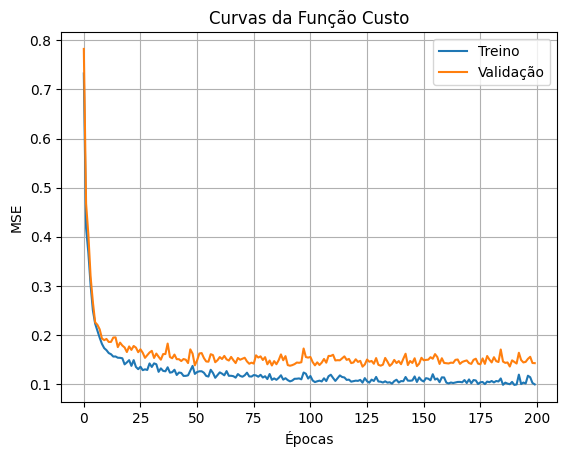

In [14]:
plt.plot(treino_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.title('Curvas da Função Custo')
plt.legend()
plt.grid()
plt.show()

In [15]:
def avaliar(X, y, conjunto):
    Z1 = relu(X @ W1 + b1)
    y_pred = Z1 @ W2 + b2
    y_pred_inv = scaler_y.inverse_transform(y_pred)
    y_inv = scaler_y.inverse_transform(y)

    mse = mean_squared_error(y_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_inv, y_pred_inv)
    mre = np.mean(np.abs((y_inv - y_pred_inv) / y_inv))  # MRE

    return {
        "Conjunto": conjunto,
        "RMSE": rmse,
        "MAE": mae,
        "MRE": mre
    }


In [16]:
resultados = []
resultados.append(avaliar(X_treino, y_treino, "Treino"))
resultados.append(avaliar(X_val, y_val, "Validação"))
resultados.append(avaliar(X_test, y_test, "Teste"))

df_resultados = pd.DataFrame(resultados)
print(df_resultados)


    Conjunto      RMSE       MAE       MRE
0     Treino  5.259453  4.015361  0.147271
1  Validação  6.303470  4.760318  0.166539
2      Teste  6.226128  4.940528  0.166781


In [17]:
file_id = "172uzXpuKK4p8M7FIDo_JzRsm8XceQHfM"
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

data_vowel = pd.read_csv(download_url, header=None)

In [18]:
X = data_vowel.iloc[:, :-1].values  # 10 atributos
y = data_vowel.iloc[:, -1].values.reshape(-1, 1)  # saída: classe (0 a 10)

In [19]:
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

In [20]:
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

In [21]:
np.random.seed(42)
indices = np.random.permutation(len(X))
n_total = len(X)
n_train = int(0.6 * n_total)
n_val = int(0.2 * n_total)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train = X[train_idx]
y_train = y_encoded[train_idx]
X_val = X[val_idx]
y_val = y_encoded[val_idx]
X_test = X[test_idx]
y_test = y_encoded[test_idx]

In [22]:
input_size = X.shape[1]      # 10
hidden_size = 20             # hiperparâmetro
output_size = y_encoded.shape[1]  # 11 classes

np.random.seed(42)
W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))


In [23]:
lr = 0.05
momentum = 0.9
alpha = 0.001
epochs = 200
batch_size = 32

In [24]:
vW1 = np.zeros_like(W1)
vb1 = np.zeros_like(b1)
vW2 = np.zeros_like(W2)
vb2 = np.zeros_like(b2)

In [25]:
def relu(z): return np.maximum(0, z)
def d_relu(z): return (z > 0).astype(float)
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
def cross_entropy(y_true, y_pred):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

In [26]:
train_losses = []
val_losses = []

In [27]:
for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[idx]
    y_train_shuffled = y_train[idx]

    for i in range(0, len(X_train), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        # Forward
        Z1 = X_batch @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        y_pred = softmax(Z2)

        # Loss + L2
        loss = cross_entropy(y_batch, y_pred) + alpha * (np.sum(W1**2) + np.sum(W2**2))

        # Backprop
        dZ2 = (y_pred - y_batch) / y_batch.shape[0]
        dW2 = A1.T @ dZ2 + 2 * alpha * W2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * d_relu(Z1)
        dW1 = X_batch.T @ dZ1 + 2 * alpha * W1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Atualização com momentum
        vW1 = momentum * vW1 - lr * dW1
        vb1 = momentum * vb1 - lr * db1
        vW2 = momentum * vW2 - lr * dW2
        vb2 = momentum * vb2 - lr * db2

        W1 += vW1
        b1 += vb1
        W2 += vW2
        b2 += vb2

    # Perdas de época
    def forward_loss(X, y):
        A1 = relu(X @ W1 + b1)
        y_pred = softmax(A1 @ W2 + b2)
        return cross_entropy(y, y_pred)

    train_losses.append(forward_loss(X_train, y_train))
    val_losses.append(forward_loss(X_val, y_val))

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss = {train_losses[-1]:.4f}, Val Loss = {val_losses[-1]:.4f}")


Epoch 0: Train Loss = 2.1875, Val Loss = 2.2168
Epoch 10: Train Loss = 0.5835, Val Loss = 0.6506
Epoch 20: Train Loss = 0.3361, Val Loss = 0.4469
Epoch 30: Train Loss = 0.2570, Val Loss = 0.3808
Epoch 40: Train Loss = 0.1955, Val Loss = 0.3121
Epoch 50: Train Loss = 0.1676, Val Loss = 0.2928
Epoch 60: Train Loss = 0.1706, Val Loss = 0.2513
Epoch 70: Train Loss = 0.1533, Val Loss = 0.2715
Epoch 80: Train Loss = 0.1399, Val Loss = 0.2590
Epoch 90: Train Loss = 0.1509, Val Loss = 0.3150
Epoch 100: Train Loss = 0.1431, Val Loss = 0.2426
Epoch 110: Train Loss = 0.1316, Val Loss = 0.2389
Epoch 120: Train Loss = 0.1213, Val Loss = 0.2415
Epoch 130: Train Loss = 0.1180, Val Loss = 0.2417
Epoch 140: Train Loss = 0.1214, Val Loss = 0.2329
Epoch 150: Train Loss = 0.1251, Val Loss = 0.2808
Epoch 160: Train Loss = 0.1253, Val Loss = 0.2211
Epoch 170: Train Loss = 0.1432, Val Loss = 0.2698
Epoch 180: Train Loss = 0.1153, Val Loss = 0.2370
Epoch 190: Train Loss = 0.1313, Val Loss = 0.2475


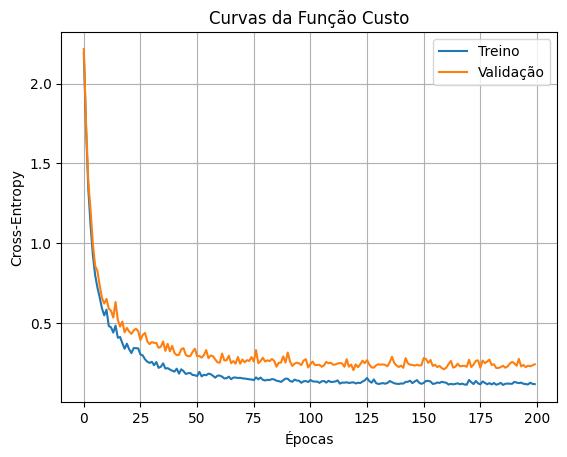

In [28]:
plt.plot(train_losses, label='Treino')
plt.plot(val_losses, label='Validação')
plt.xlabel('Épocas')
plt.ylabel('Cross-Entropy')
plt.title('Curvas da Função Custo')
plt.legend()
plt.grid()
plt.show()

In [29]:
def avaliar(X, y_true, nome):
    A1 = relu(X @ W1 + b1)
    y_pred_probs = softmax(A1 @ W2 + b2)
    y_true_labels = np.argmax(y_true, axis=1)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)
    acc = accuracy_score(y_true_labels, y_pred_labels)
    print(f"{nome} - Acurácia: {acc:.4f}")
    return y_true_labels, y_pred_labels

_, _ = avaliar(X_train, y_train, "Treino")
_, _ = avaliar(X_val, y_val, "Validação")
y_true_test, y_pred_test = avaliar(X_test, y_test, "Teste")

Treino - Acurácia: 0.9966
Validação - Acurácia: 0.9141
Teste - Acurácia: 0.9343


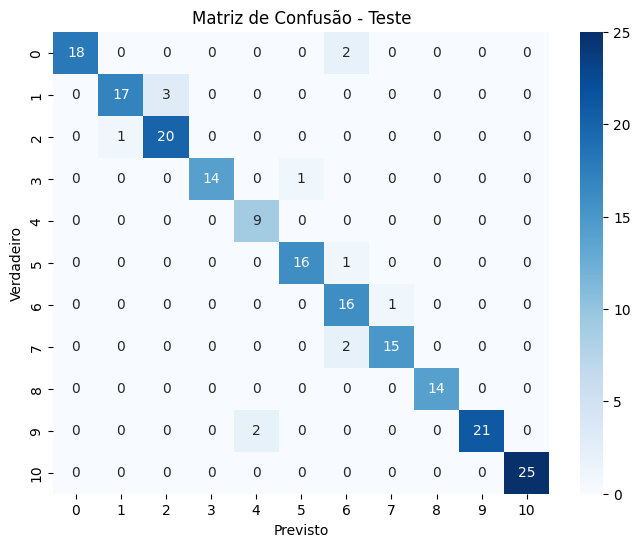

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Teste')
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.show()